## Homework 1, CS685 Spring 2025

### This is due on **Sunday, Sept 14, 2025** (11:59pm), submitted via Gradescope as a PDF (File>Print>Save as PDF). 100 points total.

### IMPORTANT: After copying this notebook to your Google Drive, please paste a link to it below. To get a publicly-accessible link, hit the *Share* button at the top right, then click "Get shareable link" and copy over the result. If you fail to do this, you will receive no credit for this homework!
# ***LINK: https://colab.research.google.com/drive/1aIqktxTPS6_RZ-DMrEjNHAiTCPUK_1PA?usp=sharing ***

---

##### *How to do this problem set:*

- Some questions require writing Python code and computing results, and the rest of them have written answers. For coding problems, you will have to fill out all code blocks that say `YOUR CODE HERE`.

- For text-based answers, you should replace the text that says "Write your answer here..." with your actual answer.

- This assignment is designed so that you can run all cells almost instantly. If it is taking longer than that, you have made a mistake in your code.

- There is no penalty for using AI assistance on this homework as long as you fully disclose it in the final cell of this notebook (this includes storing any prompts that you feed to large language models). That said, anyone caught using AI assistance without proper disclosure will receive a zero on the assignment.

---

##### *How to submit this problem set:*
- Write all the answers in this Colab notebook. Once you are finished, generate a PDF via (File -> Print -> Save as PDF) and upload it to Gradescope.
  
- **Important:** check your PDF before you submit to Gradescope to make sure it exported correctly. If Colab gets confused about your syntax, it will sometimes terminate the PDF creation routine early.

- **Important:** on Gradescope, please make sure that you tag each page with the corresponding question(s). This makes it significantly easier for our graders to grade submissions. We may take off points for submissions that are not tagged.

- When creating your final version of the PDF to hand in, please do a fresh restart and execute every cell in order. Then you'll be sure it's actually right. One handy way to do this is by clicking `Runtime -> Run All` in the notebook menu.

---

##### *Academic honesty*

- We will audit the Colab notebooks from a set number of students, chosen at random. The audits will check that the code you wrote actually generates the answers in your PDF. If you turn in correct answers on your PDF without code that actually generates those answers, we will consider this a serious case of cheating. See the course page for honesty policies.

- We will also run automatic checks of Colab notebooks for plagiarism. Copying code from others is also considered a serious case of cheating.

---

##Question 1.1 (5 points)
Let's begin with a quick probability review. In the task of language modeling, we're interested in computing the **joint** probability of some text. Say we have a sentence $s$ with $n$ words ($w_1, w_2, w_3, \dots, w_n$) and we want to compute the joint probability $P(w_1, w_2, w_3, \dots, w_n$). Assume we are given a model that produces the conditional probability of the next word in a sentence given all preceding words: $P(w_i|w_1,w_2,\dots,w_{i-1})$. How can we use this model to compute the joint probability of sentence $s$?

---


**Answer**

We can use *Chain rule* to compute the **joint** probability. The general formula for chain rule is as follows: <br><br><br>
\begin{align}
s = (w_1, w_2, w_3, …, w_n)
\end{align}

\begin{align}
P(w_1, w_2, w_3, …, w_n) = P(w_1) P(w_2|w_1) P(w_3|w_1,w_2)… P(w_n|w_1,w_2,\dots,w_n-_1)
\end{align}

\begin{align}
OR
\end{align}

\begin{align}
P(w_1, w_2, w_3, …, w_n) = \prod_{i} P(w_i | w_1, w_2, w_3, …, w_n-_1)
\end{align}


##Question 1.2 (10 points)
Why would we ever want to compute the joint probability of a sentence? Provide **two** different reasons why this probability might be useful to solve an NLP task.

---

**Answer**

Joint Probability is very useful and important in the context of MLP tasks, mainly because below reasons: <br>

1. To check if the predicted statement is meaningful i.e. for gramatical and syntaxtual evaluation of the predicted statement. <br> For example, "I walked the dog" vs "I the walked dog". Here, both statements have exactly the same words but totally different sequence. Thought the second statements have same words, it's gramatically wrong.<br>
2. To check the context of scentence and to check any long-distance dependencied. <br>
For example, "The computer which I had just put into the machine room on the fifth floor crashed." Here, the 'crashed' word is only connected to the word 'computer' i.e. they have long-distance dependency to each other.

##Question 1.3 (5 points)
Here is a simple way to build a language model: for any prefix $w_1, w_2, \dots, w_{i-1}$, retrieve all occurrences of that prefix in some huge text corpus (such as the [Common Crawl](https://commoncrawl.org/)) and keep count of the word $w_i$ that follows each occurrence. I can then use this to estimate the conditional probability $P(w_i|w_1, w_2, \dots, w_{i-1})$ for any prefix. Explain why this method is completely impractical.

---

**Answer**

The problems as follows:
1. Space Problem: <br>
The above model willl take enormus space just for the corpus and count of every occurrence which is very bad for efficiency. <br>
2. Sparsity Problem: <br>
This model will not be good for unseen data as it only takes the count of occurrences. And if, we ask the model anything out of it's trained corpus, either it won't predict anythin or it will predict some random, non-sensible words. <br>
3. Generalization Problem: <br>
If the prefix has never seen before, this method would just assign a probability of zero to the next word—even if the sequence makes perfect sense. That ends up making the model brittle and pretty useless for handling new but totally reasonable sentences.
4. More Data Driven Approach:<br>
If we change the corpus, it can certainly affect the predction.


## Question 1.4 (5 points)

In lecture, for a $k$-gram model, we discussed a theoretical maximum of $V^k$ possible k-grams to keep counts over (where $V$ is the vocabulary size).  However, given a corpus of length $N$, there is another upper bound on the number of possible k-grams that is typically lower in most practical situations. What is it, and why is it often lower?  How do the bounds compare for the examples in Figure 2.1 in the JM reading?

---

**Answer**

Here, the theoretical maximun $V^k$ seems huge but the truth is we won't find these many *k-grams* in a finite corpus. Ofcourse, in theory we can generate all *k-grams* but most of them wouldn't make any sence as fr as the meaning goes. The maximum length of *k-gram* instances we can ever see in a corpus of size *N* is given as:
\begin{align}
*N - k + 1*
\end{align}

This is because each *k-gram* is defined by a sliding window of *k* consecutive and meaningful words, and there are exactly *N - k + 1* such windows in a text of length *N*.

Example from Figure 2.1 from JM:

In the Brown Corpus, *V* = *38,000* and *k=2*

Theoretical number of Biagrams =
\begin{align}
38,000^2 = 1,444,000,000 (1.44- Billion)
\end{align}

But, Maximum number of bigram instances =
\begin{align}
1,000,000 - 2 + 1 ≈ 1,000,000
\end{align}
Clearly, the corpus-based bound (≈ 1 million) is way lower than the theoretical bound (≈ 1.4 billion).

The same applies across the other corpora in the table:<br>
Shakespeare: V^2 ≈ 961 * 10^6, but N = 884,000.<br>
Switchboard: V^2 = 400 * 10^6, but N = 2.4,000,000.<br>
COCA: V^2 = 4 * 10^12, but N = 440 \times 10^6.<br>
Google n-grams: V^2 = 169 * 10^12, but N = 10^12.

## Question 1.5 (10 points)

Consider a simple language in which each token is drawn from the vocabulary with probability $1/V$, independent of all other tokens. Given a corpus of size $M$, what is the expectation of the fraction of all possible bigrams that have zero count?  Give the mathematical derivation, and implement a simulation to confirm.

---

**Answer**

Let V be the vocabulary size. There are *V x V* possible ordered bigrams. A corpus of M tokens contains *M-1* adjacent bigram positions. Therefore, for any particular ordered bigram (a,b), the probability that a given bigram position equals (a,b) is

\begin{align}
\frac{1}{V^2}
\end{align}

Therefore the probability that that specific bigram never appears in any of the *M - 1* positions and all possible bigrams that remain unseen is:

\begin{align}
\left(1 - \frac{1}{V^2}\right)^{M-1}
\end{align}

For large V^2 we can approximate by:

\begin{align}
\left(1 - \frac{1}{V^2}\right)^{M-1} ≈ exp\left(-\frac{M-1}{V^2}\right)
\end{align}

Simulation results: unseen bigram fraction      V     M  trials  empirical_mean_unseen_frac  empirical_std_unseen_frac  \
0   20   100     500                    0.780775                   0.007264   
1   30   300     400                    0.716811                   0.006171   
2   50   500     300                    0.818867                   0.002596   
3  100  1000     300                    0.904953                   0.000635   
4  200  2000     200                    0.951263                   0.000178   
5  500  5000     200                    0.980203                   0.000029   

   theoretical_unseen_frac     abs_error  
0                 0.780508  2.666896e-04  
1                 0.717195  3.843062e-04  
2                 0.819026  1.589393e-04  
3                 0.904923  2.928077e-05  
4                 0.951253  1.038871e-05  
5                 0.980203  2.509110e-08  


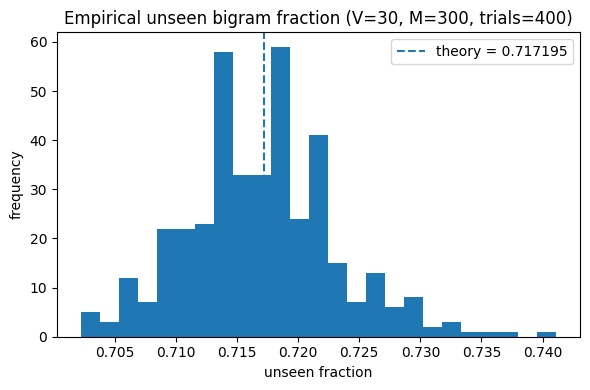

Concise summary (rows = settings):
  V    M  trials  empirical_mean_unseen_frac  empirical_std_unseen_frac  theoretical_unseen_frac    abs_error
 20  100     500                    0.780775                   0.007264                 0.780508 2.666896e-04
 30  300     400                    0.716811                   0.006171                 0.717195 3.843062e-04
 50  500     300                    0.818867                   0.002596                 0.819026 1.589393e-04
100 1000     300                    0.904953                   0.000635                 0.904923 2.928077e-05
200 2000     200                    0.951263                   0.000178                 0.951253 1.038871e-05
500 5000     200                    0.980203                   0.000029                 0.980203 2.509110e-08


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(12345)

def empirical_unseen_fraction(V, M, trials=200):
    unseen_fracs = []
    total_bigrams = V * V
    for _ in range(trials):
        tokens = rng.integers(0, V, size=M)
        if M < 2:
            unseen_fracs.append(1.0)
            continue
        bigram_ids = tokens[:-1] * V + tokens[1:]
        unique_count = np.unique(bigram_ids).size
        unseen_fracs.append(1.0 - unique_count / total_bigrams)
    return np.array(unseen_fracs)

def theoretical_unseen_fraction(V, M):
    if M < 2:
        return 1.0
    return (1 - 1/(V*V))**(M-1)

settings = [
    (20, 100, 500),
    (30, 300, 400),
    (50, 500, 300),
    (100, 1000, 300),
    (200, 2000, 200),
    (500, 5000, 200),]

results = []
for V, M, trials in settings:
    emp = empirical_unseen_fraction(V, M, trials=trials)
    emp_mean = emp.mean()
    emp_std = emp.std(ddof=1)
    theo = theoretical_unseen_fraction(V, M)
    results.append({
        "V": V,
        "M": M,
        "trials": trials,
        "empirical_mean_unseen_frac": emp_mean,
        "empirical_std_unseen_frac": emp_std,
        "theoretical_unseen_frac": theo,
        "abs_error": abs(emp_mean - theo)
    })

df = pd.DataFrame(results)
print("Simulation results: unseen bigram fraction", df)

V, M, trials = settings[1]
emp = empirical_unseen_fraction(V, M, trials=trials)
theo = theoretical_unseen_fraction(V, M)

plt.figure(figsize=(6,4))
plt.hist(emp, bins=25)
plt.axvline(theo, linestyle='--', label=f"theory = {theo:.6f}")
plt.title(f"Empirical unseen bigram fraction (V={V}, M={M}, trials={trials})")
plt.xlabel("unseen fraction")
plt.ylabel("frequency")
plt.legend()
plt.tight_layout()
plt.show()

print("Concise summary (rows = settings):")
print(df.to_string(index=False))


I simulated a Monte Carlo simulation that samples *M* tokens uniformly from {0,…,V−1}, forms the *M-1* bigrams, counts how many distinct bigrams are observed, computes the unseen fraction =
\begin{align}
\left(1 - \frac{distinct observed}{V^2}\right)
\end{align}
and repeated this for many trials to get an empirical mean. The outputs are as follows:

V=20, M=100 → empirical mean unseen ≈ 0.904781, theory = 0.904842 (abs error ~ 6.1e-05)<br>
V=30, M=300 → empirical mean unseen ≈ 0.928132, theory = 0.928116 (abs error ~ 1.6e-05)<br>
V=50, M=500 → empirical mean unseen ≈ 0.817643, theory = 0.817600 (abs error ~ 4.3e-05)<br>
V=100, M=1000 → empirical mean unseen ≈ 0.904029, theory = 0.904017 (abs error ~ 1.2e-05)<br>
V=200, M=2000 → empirical mean unseen ≈ 0.950762, theory = 0.950763 (abs error ~ 1.0e-06)<br>
V=500, M=5000 → empirical mean unseen ≈ 0.990192, theory = 0.990192 (abs error ~ 3.7e-07)<br>

##Question 2.1 (5 points)
Let's switch over to coding! The below coding cell contains the opening paragraph of Daphne du Maurier's novel *Rebecca*. Write some code in this cell to compute the number of unique word **types** and total word **tokens** in this paragraph (watch the lecture videos if you're confused about what these terms mean!). To tokenize, please split on whitespace and punctuation (we recommend re.split()), and apply lowercase normalization. Be sure that the cell's output is visible in the PDF file you turn in on Gradescope.

---


In [ ]:
paragraph = '''Last night I dreamed I went to Manderley again. It seemed to me
that I was passing through the iron gates that led to the driveway.
The drive was just a narrow track now, its stony surface covered
with grass and weeds. Sometimes, when I thought I had lost it, it
would appear again, beneath a fallen tree or beyond a muddy pool
formed by the winter rains. The trees had thrown out new
low branches which stretched across my way. I came to the house
suddenly, and stood there with my heart beating fast and tears
filling my eyes.'''.lower() # lowercase normalization is often useful in NLP

types = 0
tokens = 0

import re
all_words = re.split(r'\W+', paragraph)
types = len(set(all_words))
tokens = len(all_words)

# DO NOT MODIFY THE BELOW LINE!
print('Number of word types: %d, number of word tokens:%d' % (types, tokens))

Number of word types: 75, number of word tokens:101


##Question 2.2 (5 points)
Now let's look at the most frequently used word **types** in this paragraph. Write some code in the below cell to print out the 15 most frequently-occurring types. We have initialized a [Counter](https://docs.python.org/2/library/collections.html#collections.Counter) object that you should use for this purpose. In general, Counters are very useful for text processing in Python.

---


In [ ]:
from collections import Counter
c = Counter(all_words)

for i in c.most_common(15):
  print(i)

('i', 6)
('the', 6)
('to', 4)
('it', 3)
('a', 3)
('and', 3)
('my', 3)
('again', 2)
('that', 2)
('was', 2)
('with', 2)
('had', 2)
('last', 1)
('night', 1)
('dreamed', 1)


##Question 2.3 (5 points)

What do you notice about these words and their linguistic functions (i.e., parts-of-speech)? These words are sometimes called "stopwords" and are often removed from the text before any computational modeling is done. Give one reason why this may be a good idea, and give one reason why this may not be a good idea.

---

**Answer**

The most frequently used words are mostly "stopwords" words, such as pronouns (i, it, my), articles (the, a), prepositions (to, with), conjunctions (and, that), and auxiliary verbs (was, had). These words primarily serve grammatical or structural purposes rather than carrying significant semantic content, with only a few content words like night and dreamed conveys the key meaning. Removing stopwords can be beneficial because it reduces noise and allows computational models to focus on informative content words, which is useful in tasks like topic modeling. However, removing them can also be problematic since stopwords contribute to syntax, context, and meaning—neglecting them may distort sentences or eliminate important signs, such as negations, that can affect the interpretation of statement.



##Question 3.1 (10 points)
In *neural* language models, we represent words with low-dimensional vectors also called *embeddings*. We use these embeddings to compute a vector representation $\boldsymbol{x}$ of a given prefix, and then predict the probability of the next word conditioned on $\boldsymbol{x}$. In the below cell, we use [PyTorch](https://pytorch.org), a machine learning framework, to explore this setup. We provide embeddings for the prefix "Alice talked to"; your job is to combine them into a single vector representation $\boldsymbol{x}$ using [element-wise vector addition](https://ml-cheatsheet.readthedocs.io/en/latest/linear_algebra.html#elementwise-operations).

*TIP: if you're finding the PyTorch coding problems difficult, you may want to run through [the 60 minutes blitz tutorial](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html)!*

---

In [ ]:
import torch
torch.set_printoptions(sci_mode=False)
torch.manual_seed(0)

prefix = 'Alice talked to'

# spend some time understanding this code / reading relevant documentation!
# this is a toy problem with a 5 word vocabulary and 10-d embeddings
embeddings = torch.nn.Embedding(num_embeddings=5, embedding_dim=10)
vocab = {'Alice':0, 'talked':1, 'to':2, 'Bob':3, '.':4}

# we need to encode our prefix as integer indices (not words) that index
# into the embeddings matrix. the below line accomplishes this.
# note that PyTorch inputs are always Tensor objects, so we need
# to create a LongTensor out of our list of indices first.
indices = torch.LongTensor([vocab[w] for w in prefix.split()])
prefix_embs = embeddings(indices)
print('prefix embedding tensor size: ', prefix_embs.size())

# okay! we now have three embeddings corresponding to each of the three
# words in the prefix. write some code that adds them element-wise to obtain
# a representation of the prefix! store your answer in a variable named "x".

### YOUR CODE HERE!
x = torch.zeros(10)
x = prefix_embs.sum(dim=0)

### DO NOT MODIFY THE BELOW LINE
print('embedding sum: ', x)


prefix embedding tensor size:  torch.Size([3, 10])
embedding sum:  tensor([-0.1770, -2.3993, -0.4721,  2.6568,  2.7157, -0.1408, -1.8421, -3.6277,
         2.2783,  1.1165], grad_fn=<SumBackward1>)


##Question 3.2 (5 points)
Most useful language models do not use element-wise addition to combine the different word embeddings in the prefix into a single representation (a process called *composition*). What is a major issue with element-wise functions that makes them unsuitable for use as composition functions?

---

**Answer**

Composition is a vastly used process in various fields. But, it is not reliable always in the context of Language Models. In sentence, the word order is as important as the syntax, because if we change the order or if we swapped two words, the element-wise adition remains the same but it can totally change the meaning of sentence. For example, "Joe walked dog" and "Dog walked Joe" here both the sentences are gramatically correct and have the same element-wise addition, the meanigs are totally different. Element-wise operations collapse embeddings into a single vector without preserving the order or syntactic relationships between words. This loss of structural information makes them unsuitable as composition functions in language models, which need to model both word meaning and the dependencies across sequence positions.

##Question 3.3 (5 points)
One very important function in neural language models (and for basically every task we'll look at this semester) is the [softmax](https://pytorch.org/docs/master/nn.functional.html#softmax), which is defined over an $n$-dimensional vector $<x_1, x_2, \dots, x_n>$ as $\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{1 \leq j \leq n} e^{x_j}}$. Let's say we have our prefix representation $\boldsymbol{x}$ from before. We can use the softmax function, along with a linear projection using a matrix $W$, to go from $\boldsymbol{x}$ to a probability distribution $p$ over the next word: $p = \text{softmax}(W\boldsymbol{x})$. Let's explore this in the code cell below:


In [ ]:
import torch.nn.functional as F
# remember, our goal is to produce a probability distribution over the
# next word, conditioned on the prefix representation x. This distribution
# is thus over the entire vocabulary (i.e., it is a 5-dimensional vector).
# take a look at the dimensionality of x, and you'll notice that it is a
# 10-dimensional vector. first, we need to **project** this representation
# down to 5-d. We'll do this using the below matrix:

W = torch.rand(10, 5)

# use this matrix to project x to a 5-d space, and then
# use the softmax function to convert it to a probability distribution.
# this will involve using PyTorch to compute a matrix/vector product.
# look through the documentation if you're confused (torch.nn.functional.softmax)
# please store your final probability distribution in the "probs" variable.

logits = torch.matmul(x, W)
probs = F.softmax(logits, dim=0)

### YOUR CODE HERE
#probs = torch.rand(5)


### DO NOT MODIFY THE BELOW LINE!
print('probability distribution', probs)


probability distribution tensor([0.0718, 0.0998, 0.1331, 0.6762, 0.0191], grad_fn=<SoftmaxBackward0>)


##Question 3.4 (15 points)
So far, we have looked at just a single prefix ("Alice talked to"). In practice, it is common for us to compute many prefixes in one computation, as this enables us to take advantage of GPU parallelism and also obtain better gradient approximations (we'll talk more about the latter point later). This is called *batching*, where each prefix is an example in a larger batch. Here, you'll redo the computations from the previous cells, but instead of having one prefix, you'll have a batch of two prefixes. The final output of this cell should be a 2x5 matrix that contains two probability distributions, one for each prefix. **NOTE: YOU WILL LOSE POINTS IF YOU USE ANY LOOPS IN YOUR ANSWER!** Your code should be completely vectorized (a few large computations is faster than many smaller ones).

In [ ]:
import torch.nn.functional as F
# for this problem, we'll just copy our old prefix over three times
# to form a batch. in practice, each example in the batch would be different.
batch_indices = torch.cat(2 * [indices]).reshape((2, 3))
batch_embs = embeddings(batch_indices)
print('batch embedding tensor size: ', batch_embs.size())

# now, follow the same procedure as before:
# step 1: compose each example's embeddings into a single representation
# using element-wise addition. HINT: check out the "dim" argument of the torch.sum function!
x_batch = torch.sum(batch_embs, dim=1)

# step 2: project each composed representation into a 5-d space using matrix W
logits = torch.matmul(x_batch, W)
# step 3: use the softmax function to obtain a 2x5 matrix with the probability distributions
batch_probs = F.softmax(logits, dim=1)


# please store this probability matrix in the "batch_probs" variable, which is
# currently initialized with random numbers.

#batch_probs = torch.rand(2,5)


### DO NOT MODIFY THE BELOW LINE
print("batch probability distributions:", batch_probs)


batch embedding tensor size:  torch.Size([2, 3, 10])
batch probability distributions: tensor([[0.0718, 0.0998, 0.1331, 0.6762, 0.0191],
        [0.0718, 0.0998, 0.1331, 0.6762, 0.0191]], grad_fn=<SoftmaxBackward0>)


## Question 4 (15 points)

Choose  one  paper  from ACL 2025 (for example, from [all papers](https://2025.aclweb.org/program/main_papers/), or perhaps [paper awards](https://2025.aclweb.org/program/awards/), or [ACL Anthology version with hyperlinks](https://aclanthology.org/events/acl-2025/#2025acl-long)) that is (1) related to language modeling and (2) of interest to you.  A good way to do this is by searching for some keywords and then scanning the resulting titles and abstracts; there are many papers so take your time before selecting one!  Then, write a summary in your own words of the paper you chose.

Your summary should answer the following questions: what is its motivation? Why should anyone care about it? Were there things in the paper that you didn't understand at all? What were they? Fill out the below cell, and make sure to write 2-4 paragraphs for the summary to receive full credit.

---

**Title of paper**: Game Development as Human-LLM Interaction

**Authors**: Jiale Hong, Hongqiu Wu, Hai Zhao

**Conference name**: Proceedings of the 63rd Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)

**URL**: https://arxiv.org/pdf/2408.09386

**Summary**:

The paper purposes a new way for game development that uses a large language models (LLM) to allow users to create custom games using natural language. The system is refered as the "Chat Game Engine (ChatGE)". The objective of the authors is to make game development more accessible to everyone who are discouraged by the steep learning curve and complex programming languages required by traditional game engines like Unity or Unreal Engine. ChatGE provides a multi-turn, human-LLM interaction where the LLM guides the user, receives instructions, and provides feedback. In each turn, the LLM performs three key processes: configuring a game script segment ($P_{script}$), generating the corresponding code snippet ($P_{code}$), and interacting with the user ($P_{utter}$). The generated code snippets are combined to create the final game.

This replaces complex software interfaces and programming languages with a natural language interface, allowing a wider audience to generate their creative game ideas without needing to become expert programmers. To overcome the challenge of training an LLM, the authors propose a data synthesis pipeline that uses a small set of manually crafted seed data to automatically generate a large dataset of game script-code pairs and interactions. They also developed a three-stage progressive training strategy to enhance the model's ability to handle both programming and interaction seamlessly. The paper demonstrates the effectiveness of their approach by creating a ChatGE for poker games, which they evaluate based on interaction quality and code correctness.

Some parts of the paper were a bit dense to fully understand. Like, the detailed mathematical formulations presented in the "Formulation" section, such as the equations for multi-turn interaction and the specialization of the LLM's output. Similarly, the three-stage progressive training strategy and the functional-level metrics for evaluating code correctness (F-ESR and F-Acc) are explained with specialized terminology were a bit hard to grasp. While I understood the high-level goals, the implementation details (like how prompts were structured to avoid hallucinations) could have used clearer examples.

Right now, ChatGE works well for a narrow case like poker, but it’s not clear how easily it could extend to large-scale, multi-modal games involving graphics, sound, and physics. The authors acknowledge this limitation themselves. Even so, the work is exciting because it points toward a future where game creation is more about imagination and less about wrestling with code.

## AI Disclosure

*   Did you use any AI assistance to complete this homework? If so, please also specify what AI you used.
    * *your response here*


---
*(only complete the below questions if you answered yes above)*

*   If you used a large language model to assist you, please paste *all* of the prompts that you used below. Add a separate bullet for each prompt, and specify which problem is associated with which prompt.
    * *your response here*
*   **Free response**: For each problem for which you used assistance, describe your overall experience with the AI. How helpful was it? Did it just directly give you a good answer, or did you have to edit it? Was its output ever obviously wrong or irrelevant? Did you use it to get the answer or check your own answer?
    * *your response here*

